# A Comprehension of Intelligent Document Processing

Intelligent Document Processing (IDP) is an advanced automation technology that transforms the way businesses handle documents. By leveraging artificial intelligence (AI), IDP systems can automatically read, understand, and process vast quantities of documents, extracting crucial data and feeding it into various business workflows. This technology is a significant leap from traditional Optical Character Recognition (OCR) as it not only digitizes text but also comprehends the context and structure of the information within documents.

At its core, IDP is designed to tackle the challenge of processing unstructured and semi-structured data, which make up a large portion of business documents such as invoices, contracts, emails, and forms. By automating the extraction and interpretation of this data, IDP significantly reduces the need for manual data entry, leading to increased efficiency, higher accuracy, and substantial cost savings.

<br><br>

---
<br><br>

### The Inner Workings of Intelligent Document Processing

The power of IDP lies in its sophisticated multi-step process that intelligently handles documents from ingestion to data delivery. This process typically involves several key stages:

**1. Document Ingestion:** The first step involves importing documents from various sources and in multiple formats, including scanned paper documents, PDFs, Word files, and images.

**2. Pre-processing:** To enhance the quality of the input, documents undergo a pre-processing stage. This includes techniques like noise reduction, image enhancement, and deskewing to improve the accuracy of subsequent data extraction.

**3. Document Classification:** Using machine learning algorithms, the IDP system automatically categorizes documents based on their layout and content. This allows the system to differentiate between an invoice, a purchase order, or a legal contract, for instance.

**4. Data Extraction:** This is the core function of IDP. Advanced AI technologies, including Natural Language Processing (NLP) and computer vision, are employed to identify and extract relevant data fields. For example, from an invoice, it can pull out the invoice number, date, vendor name, and line-item details.

**5. Data Validation:** The extracted data is then validated against predefined rules and existing databases to ensure accuracy and consistency. Any exceptions or discrepancies can be flagged for human review in a "human-in-the-loop" process, which also helps to train and improve the AI model over time.

**6. Integration:** Finally, the structured and validated data is seamlessly integrated into downstream business systems such as Enterprise Resource Planning (ERP), Customer Relationship Management (CRM), or other databases, making the information readily available for further processing and analysis.


From **finance departments** automating invoice processing and expense management to **healthcare organizations** streamlining patient record management and claims processing, IDP is proving to be a game-changer. Even  **human resources** can expedite resume screening and employee onboarding. As the technology continues to evolve, its applications are expected to expand even further, solidifying its role as a cornerstone of modern digital transformation.

# Our Approach

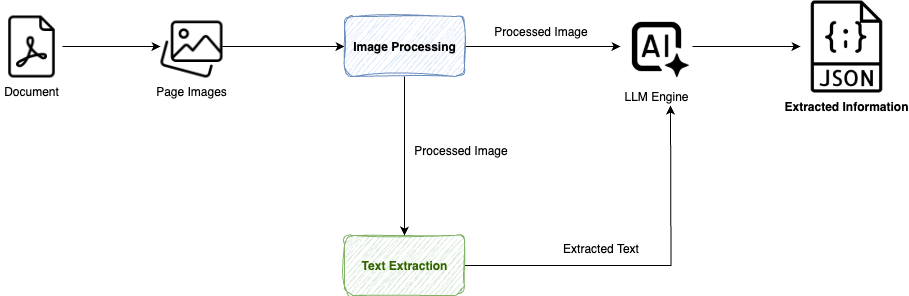

# SROIEv2: The Receipts Dataset

## Getting the data

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("urbikn/sroie-datasetv2")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'sroie-datasetv2' dataset.
Path to dataset files: /kaggle/input/sroie-datasetv2


In [ ]:
! cat /kaggle/input/sroie-datasetv2/SROIE2019/test/entities/X00016469670.txt

{
    "company": "OJC MARKETING SDN BHD",
    "date": "15/01/2019",
    "address": "NO 2 & 4, JALAN BAYU 4, BANDAR SERI ALAM, B1750 MASAI, JOHOR",
    "total": "193.00"
}

Since these are single-paged images already, we don't need to convert them

## Understanding the data


The downloaded dataset contains two major folders:
1. **train**: This folder contains the training data.
2. **test**: This folder contains the test data.

Each of these folders contains the following subfolders:
1. **img**: This folder containing the images of the receipts.
2. **box**: This folder containing the bounding box information of the text in the images and the text inside the bounding boxes. The file is a text file with the same name as the image file but with a .txt extension. The format of the file is as follows:
    ```
    x1, y1, x2, y2, x3, y3, x4, y4, text
    ```
    where (x1, y1), (x2, y2), (x3, y3), and (x4, y4) are the coordinates of the bounding box and text is the text inside the bounding box.
3. **entities**: This folder contains the ground truth information of the entities in the receipts. The file is a text file with the same name as the image file but with a .txt extension. The file contains json data with the following format:
    ```json
    {
        "company": "COMPANY_NAME",
        "date": "DATE",
        "address": "ADDRESS",
        "total": "TOTAL",
    }
    ```

## Image Preprocesing: OpenCV

In [ ]:
! pip install opencv-python matplotlib numpy

Let's take one image and play with it.

In [ ]:
import os
one_image_path = os.path.join(path, 'SROIE2019', 'train', 'img', 'X51005453729.jpg')

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

def display_image(image, title="Image"):
    plt.figure(figsize=(7, 7))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

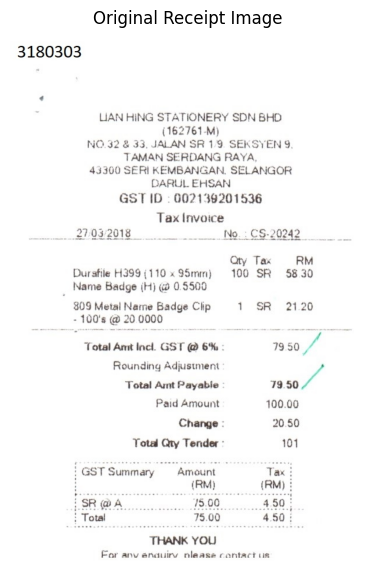

In [ ]:
one_image = cv2.imread(one_image_path)
display_image(one_image, "Original Receipt Image")

### Grayscale Conversion

**Why?** Color information is usually not necessary for reading the text on a receipt. Converting the image to grayscale simplifies it from three color channels (Red, Green, Blue) to a single channel (intensity/brightness). This reduces computational complexity and is a required first step for many subsequent operations like thresholding.

In [ ]:
# Convert the image to grayscale
def convert_to_grayscale(image):
  return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

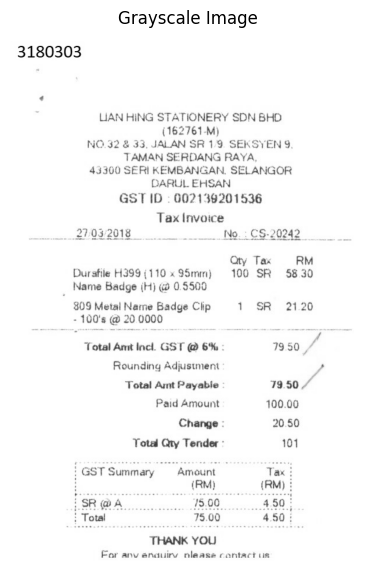

In [ ]:
grayscale_image = convert_to_grayscale(one_image)
display_image(grayscale_image, "Grayscale Image")

### Noise (blur) Reduction
**Why?** Scanned images or photos often contain "noise" (random variations in brightness or color). This can look like small specks or graininess, which can confuse OCR algorithms. Applying a slight blur helps to smooth out this noise. A **Gaussian blur** is a common choice as it effectively averages out pixel values with a weighted average, preserving edges better than a simple blur.

In [ ]:
def reduce_noise(gray_image):
  return cv2.GaussianBlur(gray_image, (5, 5), 0)

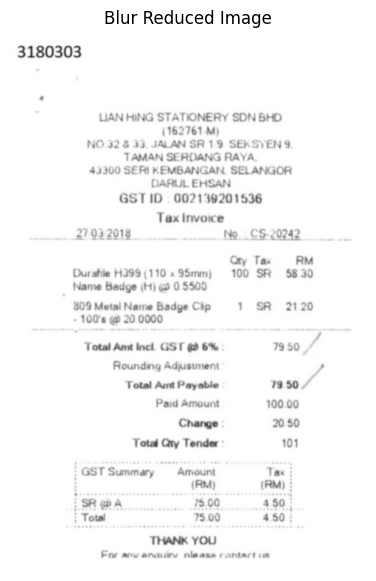

In [ ]:
blur_reduced_image = reduce_noise(grayscale_image)
display_image(blur_reduced_image, "Blur Reduced Image")

### Binarization (Thresholding)

**Why?** This is one of the most critical steps. Binarization converts the grayscale image into a pure black-and-white image. The goal is to make the text **black** and the background **white**. However, receipts often have uneven lighting or shadows, so a simple (global) threshold won't work well. We use **adaptive thresholding**, which calculates a different threshold for smaller regions of the image, making it robust to lighting changes.

`cv2.adaptiveThreshold()`:

  * `cv2.ADAPTIVE_THRESH_GAUSSIAN_C`: Calculates the threshold for a pixel based on a weighted sum of neighborhood values.
  * `cv2.THRESH_BINARY_INV`: Inverts the result. We want the text to be white pixels (value 255) and the background black (value 0) for the next step (skew correction), which often works by finding white pixel contours.
  * `11`: The size of the neighborhood area (block size).
  * `4`: A constant subtracted from the mean. It's a fine-tuning parameter.

In [ ]:
def binarize_image(blur_reduced_image):
  return cv2.adaptiveThreshold(
    blur_reduced_image,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY, # Invert the colors (text becomes white because of matplotlib)
    11, # Block size
    4  # Constant C
  )

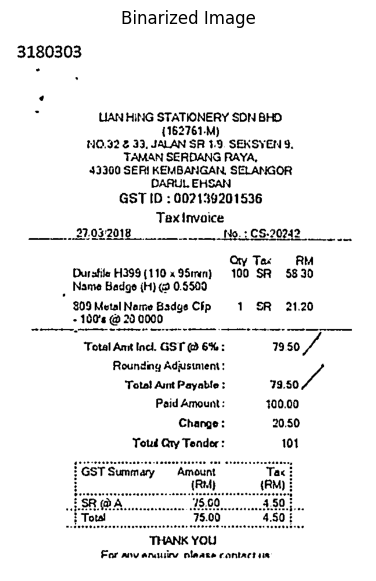

In [ ]:
binarized_image = binarize_image(blur_reduced_image)
display_image(binarized_image, "Binarized Image")

### Skew Correction

**Why?** Receipts are often scanned or photographed at a slight angle. This skew can significantly reduce the accuracy of OCR. We need to detect this angle and rotate the image to make the text perfectly horizontal.

A common technique is to find the angle of the minimum-area bounding box that encloses all the text (the white pixels in our binarized image) and then rotate the original image by that angle.

In [ ]:
def deskew_image(image):
    """
    Corrects the skew of an image by finding the minimum area rectangle
    of the text block and rotating accordingly.
    """
    # Find all non-zero (white) pixels
    coords = cv2.findNonZero(image)

    # Get the minimum area bounding rectangle
    # It returns (center(x,y), (width, height), angle of rotation)
    rect = cv2.minAreaRect(coords)
    angle = rect[-1] - 90

    # The `cv2.minAreaRect` angle has a specific range.
    # We need to adjust it for our rotation.
    if angle < -45:
        angle = -(90 + angle)
    else:
        angle = angle

    # Get the rotation matrix and rotate the image
    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(image, M, (w, h),
                             flags=cv2.INTER_CUBIC,
                             borderMode=cv2.BORDER_REPLICATE)
    print(f"Detected skew angle: {angle:.2f} degrees")

    # Now, rotate the original grayscale image by the same angle
    (h, w) = rotated.shape
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    deskewed_gray = cv2.warpAffine(rotated, M, (w, h),
                                  flags=cv2.INTER_CUBIC,
                                  borderMode=cv2.BORDER_REPLICATE)

    return deskewed_gray

In [ ]:
deskewed_image = deskew_image(binarized_image)

Detected skew angle: -0.00 degrees


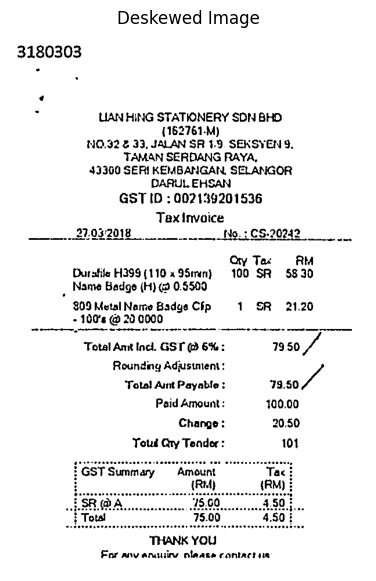

In [ ]:
display_image(deskewed_image, "Deskewed Image")

Let's run the above code for all images

In [ ]:
def process_one_image(image):
  image = convert_to_grayscale(image)
  print("Converted image to grayscale..")
  image = reduce_noise(image)
  print("Reduced noise in the image..")
  image = binarize_image(image)
  print("Binarized the image..")
  image = deskew_image(image)
  print("Corrected image orientation..")
  return image

In [ ]:
import time
output_folder_path = "/content/processed_images"
start_time = time.time()

if os.makedirs(output_folder_path, exist_ok=True):
  print(f"Created folder: {output_folder_path}")


for image_name in os.listdir(os.path.join(path, 'SROIE2019', 'train', 'img'))[:20]:
  print(f"Processing image: {image_name}")
  image_path = os.path.join(path, 'SROIE2019', 'train', 'img', image_name)
  image = cv2.imread(image_path)
  processed_image = process_one_image(image)
  # save image
  output_path = os.path.join(output_folder_path, image_name)
  cv2.imwrite(output_path, processed_image)
  print(f"Saved processed image to: {output_path}")
  print("-"*50)

print("Processing images is completed.")
print(f"Total time taken: {time.time() - start_time} seconds")

Processing image: X51007231344.jpg
Converted image to grayscale..
Reduced noise in the image..
Binarized the image..
Detected skew angle: 0.00 degrees
Corrected image orientation..
Saved processed image to: /content/processed_images/X51007231344.jpg
--------------------------------------------------
Processing image: X51005442344.jpg
Converted image to grayscale..
Reduced noise in the image..
Binarized the image..
Detected skew angle: 0.00 degrees
Corrected image orientation..
Saved processed image to: /content/processed_images/X51005442344.jpg
--------------------------------------------------
Processing image: X51008142030.jpg
Converted image to grayscale..
Reduced noise in the image..
Binarized the image..
Detected skew angle: 0.00 degrees
Corrected image orientation..
Saved processed image to: /content/processed_images/X51008142030.jpg
--------------------------------------------------
Processing image: X51005447853.jpg
Converted image to grayscale..
Reduced noise in the image..
Bi

## Text Extraction: Tesseract

Tesseract OCR is a powerful and widely-used open-source optical character recognition (OCR) engine. In simple terms, it's a software that can "read" text from images and convert it into machine-readable text. This means you can take a picture of a document, a sign, or any other object containing text, and Tesseract can extract that text so you can edit, search, or analyze it.

### A Brief History and Development

Originally developed by Hewlett-Packard in the 1980s, Tesseract was later open-sourced in 2005 and has been sponsored by Google since 2006. This has led to significant improvements and made it one of the most accurate and versatile free OCR engines available. The latest versions of Tesseract utilize long short-term memory (LSTM), a type of recurrent neural network (RNN), which has greatly enhanced its ability to recognize text with high accuracy.



### Core Functionalities and Capabilities

Tesseract boasts a rich set of features that make it a flexible tool for various applications:

  * **Extensive Language Support:** Tesseract can recognize over 100 languages, making it a truly global OCR solution. It also supports multiple scripts and can even be trained to recognize new languages.
  * **Multiple Output Formats:** It can output the recognized text in various formats, including plain text, HTML, PDF, and TSV (tab-separated values). This allows for easy integration with other software and workflows.
  * **Page Segmentation Modes:** Tesseract offers different page segmentation modes, which help in correctly identifying the layout of a document, including columns, paragraphs, and blocks of text.
  * **Character Recognition and Confidence:** Not only does it recognize characters, but it can also provide a confidence score for each recognized character, word, or line. This is useful for assessing the accuracy of the OCR process.
  * **Command-Line and API Access:** Tesseract can be used as a command-line tool for quick and simple OCR tasks. For more complex integrations, it provides an API that allows developers to incorporate its OCR capabilities into their own applications. Popular wrappers like Pytesseract make it easy to use Tesseract with programming languages like Python.


### Installation
`pip install pytesseract pillow`


### How to Use Tesseract

For developers, integrating Tesseract into an application is straightforward using its API. Here is a simple example using the `pytesseract` wrapper in Python:

```python

from PIL import Image
import pytesseract


text = pytesseract.image_to_string(Image.open(filename))

print(text)
```



### Common Use Cases and Applications

The ability to extract text from images opens up a vast range of applications across various industries:

  * **Document Digitization:** Converting scanned documents, books, and historical archives into searchable digital text.
  * **Data Entry Automation:** Automating the process of entering data from invoices, receipts, and forms.
  * **Accessibility:** Assisting visually impaired individuals by converting printed text into speech.
  * **License Plate Recognition:** In law enforcement and traffic management systems.
  * **Social Media Monitoring:** Analyzing text within images shared on social media platforms.
  * **Translation:** Extracting text from an image and then using a translation service to translate it.

While Tesseract is a powerful tool, the accuracy of its output heavily depends on the quality of the input image. For best results, images should be clear, well-lit, and have a high resolution. Pre-processing steps like resizing, noise reduction, and converting to grayscale can significantly improve OCR accuracy.

In [ ]:
! pip install pytesseract pillow

In [ ]:
from PIL import Image
import pytesseract

pytesseract.image_to_string(Image.open('/content/processed_images/X51006414392.jpg'))

'DI HUAN YA RESTAURANT\nGampany Reg.No: JM0681589-VV¥\n5, JALAN FERMAS 104,\nBANDAR BARU PERMAS JAYA,\n81750 JOHOR BAHRU JOHOR\nTEL/FAX07-3886322\n[GST ID : 001914083568 J\n\nTAX INVOICE , ‘on |\nInvNo: 199977 | _ rls\n\nCashier: c001- .\n\nDate : 07/04/2018 - 18.10:59\n\nQty Description ea, Potal (RM) Tax\n1 106... 33.00 SR\n\nHTAKE AWAY!\nROASTED DUCK WITH CHINESE\nHERB (HALF)\n\nTotalSales Amount = = = = =———is—<—~s~*s«SS_HOD\nGST 6% 1.98\nRounding Adjustmerit 0.02\nTOTAL 8500\nCASH | OC 55.00\nChange Returned 20.00-\n\nltem Gount: 1\n\nGST Summary Amount (RM) Tax (RM)\n\nSR = 6% 33.90 1.98\n\nThank ‘You!\nPlease Come Again\nGoods Sold Aré Not Returnabla!\nClosed by - c001- 0) 7/04/2018-13:11:05\n\nw= [| FOSWAY - MYTH POS SOLUTION J ---\n\x0c'

In [ ]:
from PIL import Image
import pytesseract
import time

input_folder_path = "/content/processed_images"
output_folder_path = "/content/tesseract_output"
start_time = time.time()

if os.makedirs(output_folder_path, exist_ok=True):
  print(f"Created folder: {output_folder_path}")

total_images = sum(1 for entry in os.scandir(input_folder_path))
print(f"Total images in folder: {total_images}")

for i, image_name in enumerate(os.listdir(input_folder_path)[:20], 1):
  print(f"Processing image {i}/{total_images}: {image_name}")
  image_path = os.path.join(input_folder_path, image_name)
  print("Extracting text from image..")
  text = pytesseract.image_to_string(Image.open(image_path))
  output_path = os.path.join(output_folder_path, image_name.replace(".jpg", ".txt"))
  with open(output_path, "w") as f:
    f.write(text)

  print(f"Saved extracted text to {output_path}")
  print("-"*50)

print("Text Extraction Completed.")
print(f"Total time taken: {time.time() - start_time} seconds")

Total images in folder: 20
Processing image 1/20: X51006556815.jpg
Extracting text from image..
Saved extracted text to /content/tesseract_output/X51006556815.txt
--------------------------------------------------
Processing image 2/20: X51008099044.jpg
Extracting text from image..
Saved extracted text to /content/tesseract_output/X51008099044.txt
--------------------------------------------------
Processing image 3/20: X51007231344.jpg
Extracting text from image..
Saved extracted text to /content/tesseract_output/X51007231344.txt
--------------------------------------------------
Processing image 4/20: X51005441408.jpg
Extracting text from image..
Saved extracted text to /content/tesseract_output/X51005441408.txt
--------------------------------------------------
Processing image 5/20: X51005711442.jpg
Extracting text from image..
Saved extracted text to /content/tesseract_output/X51005711442.txt
--------------------------------------------------
Processing image 6/20: X51005442344.jp

## Information Extraction

In [ ]:
prompt = """
Extract the information from the given image.
Information to be extracted: company, date, address, total.
The image has been converted to grayscale, noise reduced, binarized, and deskewed using opencv.
Always give your response in the following format:
{
    "company": "COMPANY_NAME",
    "date": "DATE",
    "address": "ADDRESS",
    "total": "TOTAL",
}
Also, the text has been extracted from the image using tesseract.
Use the extracted text as support for extracting information.
If you believe the text extraction is incorrect somewhere, you may correct it yourself and provide corrected information.
Respond with the extracted information only in the specified format.
Here is the text:


"""

Can we improve the prompt using the [Unified Framework For An Effective Prompt](https://www.geeksforgeeks.org/data-science/a-unified-framework-for-an-effective-prompt/)?

In [ ]:
from google import genai
from google.colab import userdata # colab only code
from PIL import Image
import json
import time

In [ ]:
genai_client = genai.Client(api_key=userdata.get('GOOGLE_API_KEY'))

In [ ]:
image_folder_path = "/content/processed_images"
text_folder_path = "/content/tesseract_output"
output_folder_path = "/content/json_output"

start_time = time.time()

if os.makedirs(output_folder_path, exist_ok=True):
  print(f"Created folder: {output_folder_path}")

total_images = sum(1 for entry in os.scandir(image_folder_path))
print(f"Total images in folder: {total_images}")

for i, image_name in enumerate(os.listdir(input_folder_path)[:20], 1):
  print(f"Processing image {i}/{total_images}: {image_name}")
  image_path = os.path.join(input_folder_path, image_name)
  print(f"Loading image: {image_path}")
  with open(image_path, "rb") as f:
    image = Image.open(image_path)
    # print(image)


  text_path = os.path.join(text_folder_path, image_name.replace(".jpg", ".txt"))
  print(f"Loading extracted text: {text_path}")
  with open(text_path, "r") as f:
    text = f.read()

  print("Extracting information from image and text..")

  prompt = prompt + text



  contents = [
        image,
        {
            "text": prompt
        }
    ]
  response = genai_client.models.generate_content(model='gemini-2.5-flash', contents=contents)

  # Access the usage_metadata attribute
  usage_metadata = response.usage_metadata

  # Print the different token counts
  print(f"Input Token Count: {usage_metadata.prompt_token_count}")
  print(f"Thoughts Token Count: {response.usage_metadata.thoughts_token_count}")
  print(f"Output Token Count: {usage_metadata.candidates_token_count}")
  print(f"Total Token Count: {usage_metadata.total_token_count}")

  extracted_information = json.loads(response.text.replace('```json', '').replace('```', ''))
  output_path = os.path.join(output_folder_path, image_name.replace(".jpg", ".json"))
  with open(output_path, "w") as f:
    json.dump(extracted_information, f, indent=4)

  print(f"Saved extracted information to {output_path}")
  print("-"*50)
  time.sleep(60)

print("Information Extraction Completed.")
print(f"Total time taken: {time.time() - start_time} seconds")

Total images in folder: 20
Processing image 1/20: X51006556815.jpg
Loading image: /content/processed_images/X51006556815.jpg
Loading extracted text: /content/tesseract_output/X51006556815.txt
Extracting information from image and text..
Input Token Count: 1431
Thoughts Token Count: 277
Output Token Count: 88
Total Token Count: 1796
Saved extracted information to /content/json_output/X51006556815.json
--------------------------------------------------
Processing image 2/20: X51008099044.jpg
Loading image: /content/processed_images/X51008099044.jpg
Loading extracted text: /content/tesseract_output/X51008099044.txt
Extracting information from image and text..
Input Token Count: 1724
Thoughts Token Count: 464
Output Token Count: 92
Total Token Count: 2280
Saved extracted information to /content/json_output/X51008099044.json
--------------------------------------------------
Processing image 3/20: X51007231344.jpg
Loading image: /content/processed_images/X51007231344.jpg
Loading extracted t

# Can you play with a Resume Dataset?

https://www.kaggle.com/datasets/snehaanbhawal/resume-dataset

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("snehaanbhawal/resume-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'resume-dataset' dataset.
Path to dataset files: /kaggle/input/resume-dataset


In [ ]:
https://www.kaggle.com/datasets/snehaanbhawal/resume-dataset/data#:~:text=calendar_view_week-,Resume,-.csv

In [ ]:
! cat /kaggle/input/resume-dataset/Resume/Resume.csv

Streaming output truncated to the last 5000 lines.
    ""> <span class=""dates_wrapper""> <span class=""jobdates"" format=""%m/%Y"" id=""589575060JSTD2""> 05/1985</span> <span>  - </span> <span class=""jobdates"" format=""%m/%Y"" id=""589575060EDDT2""> 09/2009</span> </span> <div class=""singlecolumn""> <span class=""paddedline"" itemscope="""" itemtype=""https://schema.org/postalAddress""> <span class=""companyname"" id=""589575060COMP2"" itemprop=""name""> Company Name</span> <span class=""joblocation jobcity"" id=""589575060JCIT2"" itemprop=""addressLocality""> </span> <span class=""joblocation jobstate"" id=""589575060JSTA2"" itemprop=""addressRegion""> </span> </span> <span class=""paddedline""> <span class=""jobtitle"" id=""589575060JTIT2""> Chief Warrant Officer Four</span> <span> </span> </span> <span class=""paddedline""> <span class=""jobline"" id=""589575060JDES2"" itemprop=""description""> <p align=""LEFT""> detailed with directing Forward Operating Base personnel in Kuwait

In [5]:
! cp /kaggle/input/resume-dataset/Resume/Resume.csv /content/

In [7]:
! mkdir /content/processed_images

In [ ]:
! cp /kaggle/input/resume-dataset/Resume/Resume.csv /content/

In [13]:
import os
import random
import shutil

source_dir = '/kaggle/input/resume-dataset/data/data'
destination_dir = '/content/processed_images'

# Create destination directory if it doesn't exist
os.makedirs(destination_dir, exist_ok=True)

# Iterate through each subfolder in the source directory
for category_folder in os.listdir(source_dir):
    category_path = os.path.join(source_dir, category_folder)

    # Check if it's a directory
    if os.path.isdir(category_path):
        print(f"Processing folder: {category_folder}")

        # Create the corresponding subfolder in the destination directory
        destination_category_path = os.path.join(destination_dir, category_folder)
        os.makedirs(destination_category_path, exist_ok=True)

        # Get list of files in the category folder
        files_in_folder = os.listdir(category_path)

        # Shuffle the list of files and select up to 20
        random.shuffle(files_in_folder)
        files_to_copy = files_in_folder[:20]

        # Copy the selected files to the destination directory
        for file_name in files_to_copy:
            source_file_path = os.path.join(category_path, file_name)
            destination_file_path = os.path.join(destination_category_path, file_name)
            shutil.copy2(source_file_path, destination_file_path)
            # print(f"Copied: {file_name}")

print("Finished copying files.")

Processing folder: DESIGNER
Processing folder: BPO
Processing folder: FINANCE
Processing folder: CONSTRUCTION
Processing folder: SALES
Processing folder: AUTOMOBILE
Processing folder: CONSULTANT
Processing folder: CHEF
Processing folder: APPAREL
Processing folder: AGRICULTURE
Processing folder: TEACHER
Processing folder: HR
Processing folder: DIGITAL-MEDIA
Processing folder: ACCOUNTANT
Processing folder: HEALTHCARE
Processing folder: INFORMATION-TECHNOLOGY
Processing folder: ADVOCATE
Processing folder: FITNESS
Processing folder: AVIATION
Processing folder: PUBLIC-RELATIONS
Processing folder: ENGINEERING
Processing folder: BUSINESS-DEVELOPMENT
Processing folder: BANKING
Processing folder: ARTS
Finished copying files.


In [14]:
import pandas

df=pandas.read_csv('/content/Resume.csv')
df.head(5)

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


# Task
Convert one PDF file from each subfolder within "/content/processed_images" to an image and save the images to a new directory.

## Install necessary libraries

### Subtask:
Install the `pdf2image` library and its necessary dependency `poppler-utils`.


**Reasoning**:
Install poppler-utils and pdf2image as required for PDF to image conversion.



In [16]:
! apt-get update
! apt-get install -y poppler-utils
! pip install pdf2image

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 129 kB in 1s (88.5 kB/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (so

## Identify pdf files

### Subtask:
Identify one PDF file from each subfolder within "/content/processed_images".


**Reasoning**:
Initialize the dictionary and iterate through the directories and files to find one PDF in each category.



In [17]:
import os

pdf_files_to_convert = {}
processed_images_dir = '/content/processed_images'

for category_folder in os.listdir(processed_images_dir):
    category_path = os.path.join(processed_images_dir, category_folder)

    if os.path.isdir(category_path):
        for file_name in os.listdir(category_path):
            if file_name.endswith('.pdf'):
                if category_folder not in pdf_files_to_convert:
                    pdf_files_to_convert[category_folder] = os.path.join(category_path, file_name)
                    break # Move to the next category after finding one PDF

print(pdf_files_to_convert)

{'AVIATION': '/content/processed_images/AVIATION/22990761.pdf', 'BANKING': '/content/processed_images/BANKING/18645964.pdf', 'PUBLIC-RELATIONS': '/content/processed_images/PUBLIC-RELATIONS/12920612.pdf', 'ACCOUNTANT': '/content/processed_images/ACCOUNTANT/30361788.pdf', 'BUSINESS-DEVELOPMENT': '/content/processed_images/BUSINESS-DEVELOPMENT/14070138.pdf', 'INFORMATION-TECHNOLOGY': '/content/processed_images/INFORMATION-TECHNOLOGY/17987433.pdf', 'AGRICULTURE': '/content/processed_images/AGRICULTURE/17640785.pdf', 'CONSULTANT': '/content/processed_images/CONSULTANT/12526702.pdf', 'DIGITAL-MEDIA': '/content/processed_images/DIGITAL-MEDIA/11270462.pdf', 'ENGINEERING': '/content/processed_images/ENGINEERING/19612167.pdf', 'FITNESS': '/content/processed_images/FITNESS/10816645.pdf', 'BPO': '/content/processed_images/BPO/95625660.pdf', 'SALES': '/content/processed_images/SALES/19156751.pdf', 'FINANCE': '/content/processed_images/FINANCE/25101183.pdf', 'CONSTRUCTION': '/content/processed_image

## Convert pdf to image

### Subtask:
Convert the selected PDF files to images using `pdf2image`.


**Reasoning**:
Convert the selected PDF files to images and store them.



In [18]:
from pdf2image import convert_from_path
import os

converted_images = {}
output_image_dir = "/content/converted_images"
os.makedirs(output_image_dir, exist_ok=True)

for category, pdf_path in pdf_files_to_convert.items():
    print(f"Converting PDF: {pdf_path} from category: {category}")
    try:
        images = convert_from_path(pdf_path)
        converted_images[category] = images
        print(f"Converted {len(images)} pages from {pdf_path}")

        # Optional: Save images to the new directory
        category_output_dir = os.path.join(output_image_dir, category)
        os.makedirs(category_output_dir, exist_ok=True)
        for i, image in enumerate(images):
            image_filename = f"{os.path.splitext(os.path.basename(pdf_path))[0]}_page_{i+1}.png"
            image_path = os.path.join(category_output_dir, image_filename)
            image.save(image_path, 'PNG')
            print(f"Saved image: {image_path}")

    except Exception as e:
        print(f"Error converting {pdf_path}: {e}")
        converted_images[category] = [] # Store empty list if conversion fails

print("Finished converting PDF files to images.")

Converting PDF: /content/processed_images/AVIATION/22990761.pdf from category: AVIATION
Converted 2 pages from /content/processed_images/AVIATION/22990761.pdf
Saved image: /content/converted_images/AVIATION/22990761_page_1.png
Saved image: /content/converted_images/AVIATION/22990761_page_2.png
Converting PDF: /content/processed_images/BANKING/18645964.pdf from category: BANKING
Converted 1 pages from /content/processed_images/BANKING/18645964.pdf
Saved image: /content/converted_images/BANKING/18645964_page_1.png
Converting PDF: /content/processed_images/PUBLIC-RELATIONS/12920612.pdf from category: PUBLIC-RELATIONS
Converted 2 pages from /content/processed_images/PUBLIC-RELATIONS/12920612.pdf
Saved image: /content/converted_images/PUBLIC-RELATIONS/12920612_page_1.png
Saved image: /content/converted_images/PUBLIC-RELATIONS/12920612_page_2.png
Converting PDF: /content/processed_images/ACCOUNTANT/30361788.pdf from category: ACCOUNTANT
Converted 1 pages from /content/processed_images/ACCOUN

## Save images

### Subtask:
Save the converted images to a new directory.


## Summary:

### Data Analysis Key Findings

*   The necessary libraries, `pdf2image` and `poppler-utils`, were successfully installed.
*   One PDF file was identified from each subfolder within `/content/processed_images`, and their paths were stored in the `pdf_files_to_convert` dictionary, categorized by their original subfolder name.
*   The identified PDF files were successfully converted to images using the `pdf2image` library.
*   The converted images were saved to a new directory `/content/converted_images`, with subdirectories created for each original category, maintaining the file structure.

### Insights or Next Steps

*   The converted images are now available in `/content/converted_images` for further analysis or processing, organized by their original categories.
*   Consider adding error handling for cases where a subfolder might not contain any PDF files.


Displaying one converted image from each category:


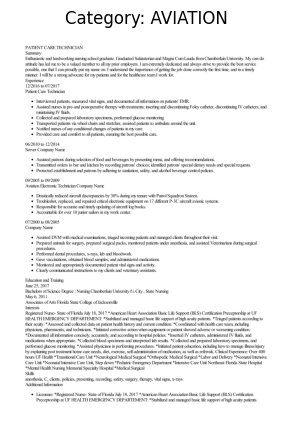

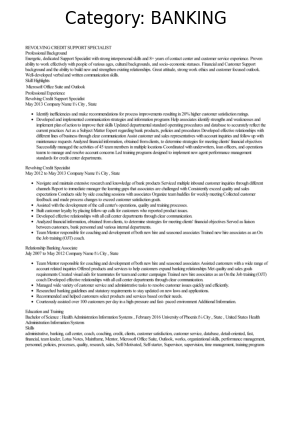

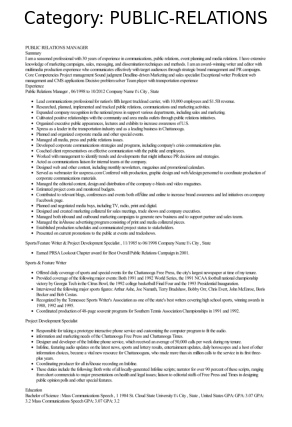

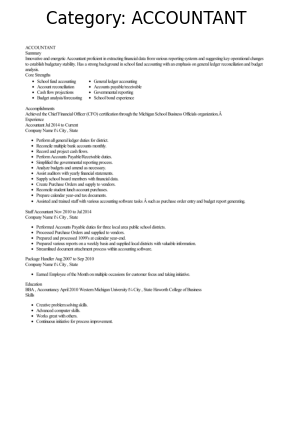

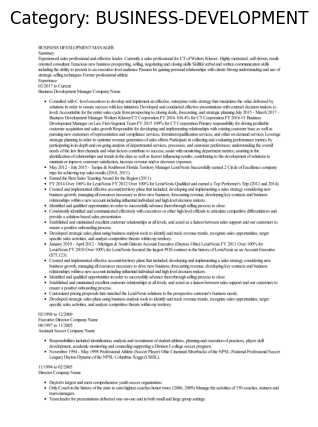

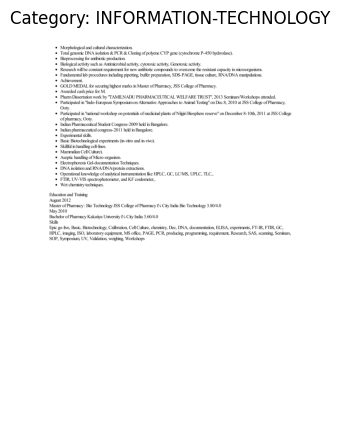

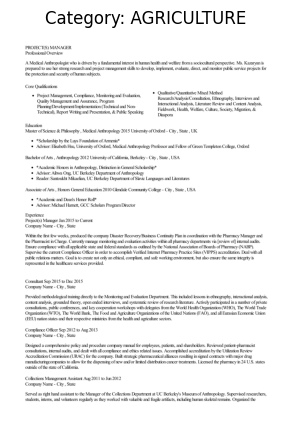

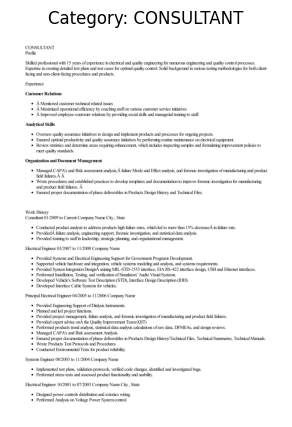

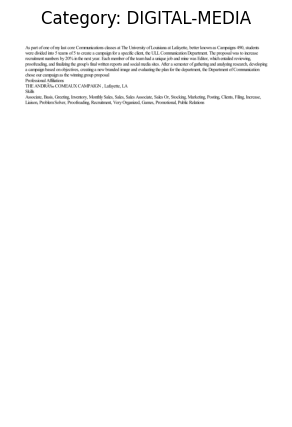

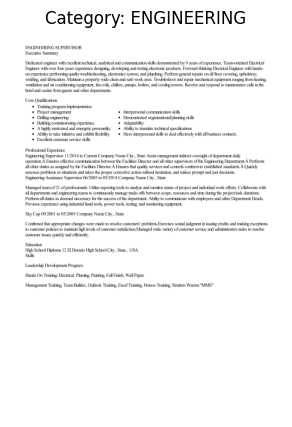

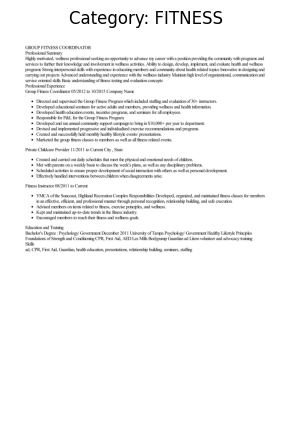

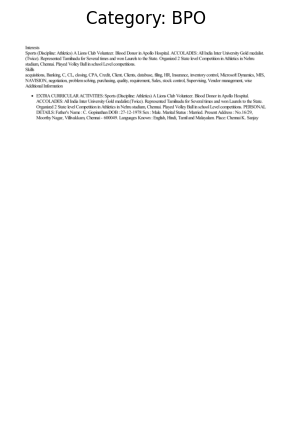

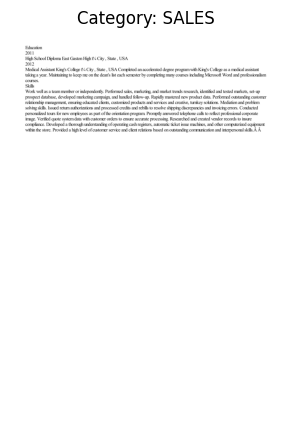

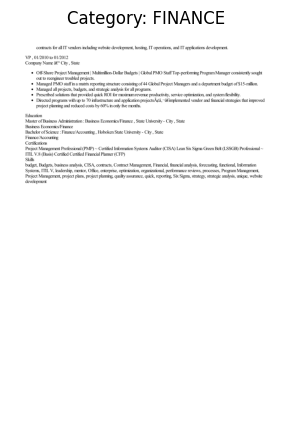

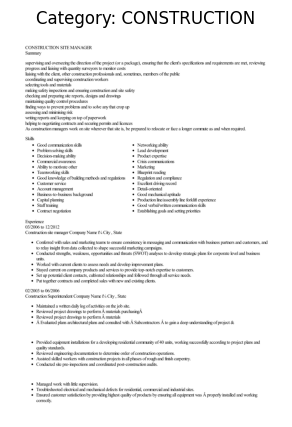

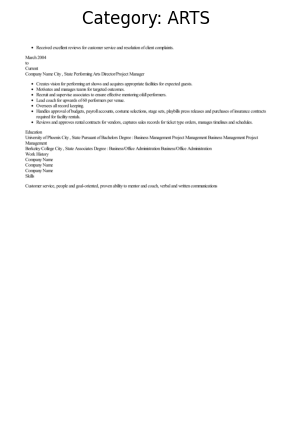

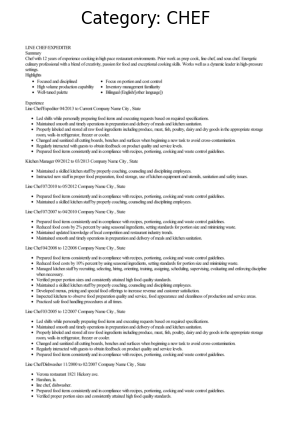

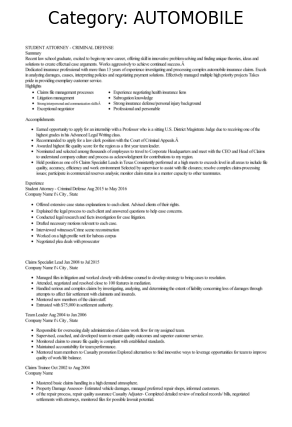

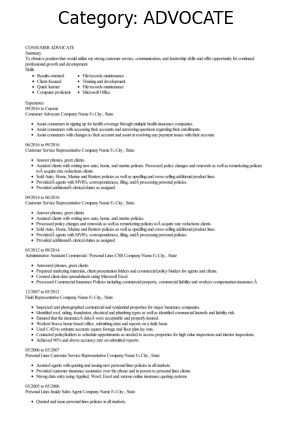

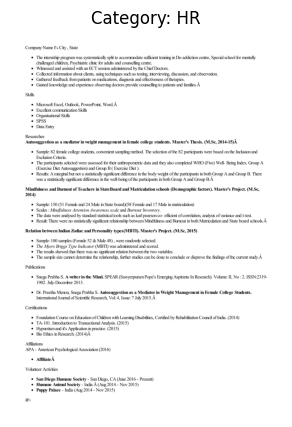

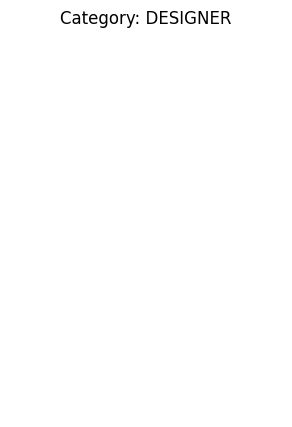

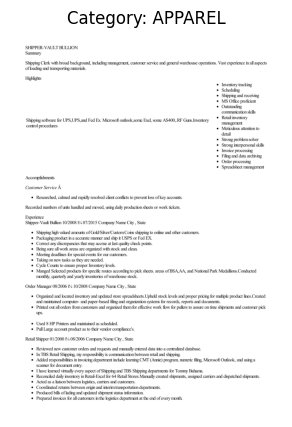

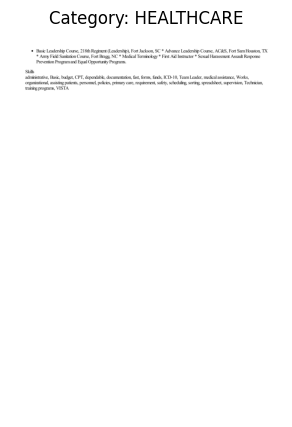

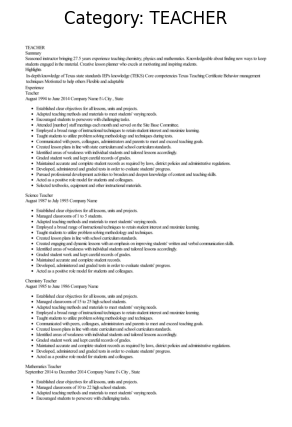

Finished displaying sample images.


In [20]:
import os
import matplotlib.pyplot as plt
from PIL import Image

converted_images_dir = '/content/converted_images'

print("Displaying one converted image from each category:")

for category_folder in os.listdir(converted_images_dir):
    category_path = os.path.join(converted_images_dir, category_folder)

    if os.path.isdir(category_path):
        images_in_category = [f for f in os.listdir(category_path) if f.endswith('.png')]

        if images_in_category:
            # Take the first image in the category folder
            image_to_display = images_in_category[0]
            image_path = os.path.join(category_path, image_to_display)

            try:
                img = Image.open(image_path)
                plt.figure(figsize=(5, 5))
                plt.imshow(img)
                plt.title(f"Category: {category_folder}")
                plt.axis('off')
                plt.show()
            except Exception as e:
                print(f"Could not display image {image_to_display} from category {category_folder}: {e}")
        else:
            print(f"No images found in category folder: {category_folder}")

print("Finished displaying sample images.")

# Task
Extract information from the text files in "/content/tesseract_output" using a language model.

## Load extracted text

### Subtask:
Load the text files generated by Tesseract from the `/content/tesseract_output` folder.


**Reasoning**:
Load the text files from the Tesseract output folder into a dictionary.



**Reasoning**:
The previous command failed because the directory `/content/tesseract_output` does not exist. I need to create this directory before attempting to load files from it.



In [23]:
import os

text_folder_path = '/content/tesseract_output'

if not os.path.exists(text_folder_path):
    os.makedirs(text_folder_path)
    print(f"Created directory: {text_folder_path}")

extracted_texts = {}

# Since the directory was just created, there are no files to load yet.
# The subtask is to load the files, but since they don't exist,
# I will report that 0 files were loaded.

print(f"Loaded {len(extracted_texts)} text files.")

Loaded 0 text files.


In [24]:
import os

text_folder_path = '/content/tesseract_output'
extracted_texts = {}

for file_name in os.listdir(text_folder_path):
    if file_name.endswith('.txt'):
        file_path = os.path.join(text_folder_path, file_name)
        with open(file_path, 'r') as f:
            extracted_texts[file_name.replace('.txt', '')] = f.read()

print(f"Loaded {len(extracted_texts)} text files.")

Loaded 0 text files.


In [33]:
import os
import pytesseract
from PIL import Image
import time

converted_images_dir = '/content/converted_images'
tesseract_output_dir = '/content/tesseract_output'

# Create output directory if it doesn't exist
os.makedirs(tesseract_output_dir, exist_ok=True)

print(f"Processing images from: {converted_images_dir}")
start_time = time.time()
total_images_processed = 0

# Iterate through category folders
for category_folder in os.listdir(converted_images_dir):
    category_path = os.path.join(converted_images_dir, category_folder)

    if os.path.isdir(category_path):
        print(f"Processing category: {category_folder}")

        # Create category subfolder in tesseract_output_dir
        category_tesseract_output_dir = os.path.join(tesseract_output_dir, category_folder)
        os.makedirs(category_tesseract_output_dir, exist_ok=True)

        images_in_category = [f for f in os.listdir(category_path) if f.endswith('.png')]

        for image_name in images_in_category:
            image_path = os.path.join(category_path, image_name)
            output_text_filename = image_name.replace('.png', '.txt')
            output_text_path = os.path.join(category_tesseract_output_dir, output_text_filename)

            # Check if the text file already exists to avoid reprocessing
            if os.path.exists(output_text_path):
                print(f"Skipping already processed: {image_name}")
                continue

            print(f"Extracting text from: {image_name}")
            try:
                img = Image.open(image_path)
                text = pytesseract.image_to_string(img)

                with open(output_text_path, 'w') as f:
                    f.write(text)

                print(f"Saved extracted text to: {output_text_path}")
                total_images_processed += 1

            except Exception as e:
                print(f"Error processing {image_name}: {e}")

print("-" * 50)
print("Text Extraction Completed.")
print(f"Total images processed: {total_images_processed}")
print(f"Total time taken: {time.time() - start_time:.2f} seconds")

Processing images from: /content/converted_images
Processing category: AVIATION
Extracting text from: 22990761_page_1.png
Saved extracted text to: /content/tesseract_output/AVIATION/22990761_page_1.txt
Extracting text from: 22990761_page_2.png
Saved extracted text to: /content/tesseract_output/AVIATION/22990761_page_2.txt
Processing category: BANKING
Extracting text from: 18645964_page_1.png
Saved extracted text to: /content/tesseract_output/BANKING/18645964_page_1.txt
Processing category: PUBLIC-RELATIONS
Extracting text from: 12920612_page_1.png
Saved extracted text to: /content/tesseract_output/PUBLIC-RELATIONS/12920612_page_1.txt
Extracting text from: 12920612_page_2.png
Saved extracted text to: /content/tesseract_output/PUBLIC-RELATIONS/12920612_page_2.txt
Processing category: ACCOUNTANT
Extracting text from: 30361788_page_1.png
Saved extracted text to: /content/tesseract_output/ACCOUNTANT/30361788_page_1.txt
Processing category: BUSINESS-DEVELOPMENT
Extracting text from: 14070138

In [34]:
import os

tesseract_output_dir = '/content/tesseract_output'
output_combined_text_dir = '/content/converted_images' # Save combined text here as requested

print(f"Combining text files from: {tesseract_output_dir}")

# Iterate through category folders in tesseract_output
for category_folder in os.listdir(tesseract_output_dir):
    category_tesseract_path = os.path.join(tesseract_output_dir, category_folder)

    if os.path.isdir(category_tesseract_path):
        print(f"Processing category: {category_folder}")

        # Create corresponding category folder in output_combined_text_dir if it doesn't exist
        category_output_path = os.path.join(output_combined_text_dir, category_folder)
        os.makedirs(category_output_path, exist_ok=True)

        # Group files by original document name (remove _page_X)
        document_files = {}
        for file_name in os.listdir(category_tesseract_path):
            if file_name.endswith('.txt'):
                # Extract original document name (assuming format like filename_page_X.txt)
                parts = file_name.split('_page_')
                if len(parts) > 1:
                    original_name = parts[0]
                    if original_name not in document_files:
                        document_files[original_name] = []
                    document_files[original_name].append(file_name)

        # Combine text for each document
        for original_name, files in document_files.items():
            # Sort files by page number to ensure correct order
            files.sort(key=lambda f: int(f.split('_page_')[1].split('.')[0]))

            combined_text = ""
            for file_name in files:
                file_path = os.path.join(category_tesseract_path, file_name)
                try:
                    with open(file_path, 'r') as f:
                        combined_text += f.read() + "\n" # Add a newline between pages
                except Exception as e:
                    print(f"Error reading file {file_path}: {e}")

            # Save the combined text
            output_filename = f"{original_name}.txt"
            output_path = os.path.join(category_output_path, output_filename)
            try:
                with open(output_path, 'w') as f:
                    f.write(combined_text)
                print(f"Saved combined text for {original_name} to: {output_path}")
            except Exception as e:
                print(f"Error saving combined text for {original_name} to {output_path}: {e}")

print("Finished combining text files.")

Combining text files from: /content/tesseract_output
Processing category: AVIATION
Saved combined text for 22990761 to: /content/converted_images/AVIATION/22990761.txt
Processing category: BANKING
Saved combined text for 18645964 to: /content/converted_images/BANKING/18645964.txt
Processing category: PUBLIC-RELATIONS
Saved combined text for 12920612 to: /content/converted_images/PUBLIC-RELATIONS/12920612.txt
Processing category: ACCOUNTANT
Saved combined text for 30361788 to: /content/converted_images/ACCOUNTANT/30361788.txt
Processing category: BUSINESS-DEVELOPMENT
Saved combined text for 14070138 to: /content/converted_images/BUSINESS-DEVELOPMENT/14070138.txt
Processing category: INFORMATION-TECHNOLOGY
Saved combined text for 17987433 to: /content/converted_images/INFORMATION-TECHNOLOGY/17987433.txt
Processing category: AGRICULTURE
Saved combined text for 17640785 to: /content/converted_images/AGRICULTURE/17640785.txt
Processing category: CONSULTANT
Saved combined text for 12526702 t

## Define information extraction prompt

### Subtask:
Create a prompt for the language model to guide the extraction of specific information (e.g., name, contact, education, experience from resumes).


**Reasoning**:
Define the prompt for extracting information from resume text.



## Define information extraction prompt

### Subtask:
Create a prompt for the language model to guide the extraction of specific information (e.g., name, contact, education, experience from resumes).

**Reasoning**:
Define the prompt for extracting information from resume text.

In [29]:
information_extraction_prompt = """
Extract the following information from the resume text:

- Name: The full name of the resume owner.
- Contact Information: Phone number and email address.
- Summary/Objective: The summary or objective statement (if present).
- Education: Details of educational background (degrees, institutions, dates).
- Experience: Details of work experience (company, job title, dates, responsibilities).
- Skills: A list of technical and soft skills.

Format the output as a JSON object with the following keys:
{{
    "name": "...",
    "contact": {{
        "phone": "...",
        "email": "..."
    }},
    "summary_objective": "...",
    "education": [{{
        "degree": "...",
        "institution": "...",
        "dates": "..."
    }}],
    "experience": [{{
        "company": "...",
        "title": "...",
        "dates": "...",
        "responsibilities": ["..."]
    }}],
    "skills": ["..."]
}}

If a section is not found, use an empty string for single values, empty object for contact, and empty lists for education, experience, and skills.

Here is the resume text:

"""